In [2]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

print("Kütüphaneler başarıyla yüklendi.")

# Veri setini yükle
with open("RML2016.10a_dict.pkl", "rb") as f:
    Xd = pickle.load(f, encoding='latin1')

# Modülasyonları ve SNR değerlerini listelere al
snrs = sorted(list(set([k[1] for k in Xd.keys()])))
mods = sorted(list(set([k[0] for k in Xd.keys()])))

print("Modülasyon Tipleri:", mods)
print("SNR Seviyeleri:", snrs)

Kütüphaneler başarıyla yüklendi.


C:\Users\habib\AppData\Local\Temp\ipykernel_19976\220372145.py:11: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  Xd = pickle.load(f, encoding='latin1')


Modülasyon Tipleri: ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']
SNR Seviyeleri: [-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18]


In [5]:
total_samples = 0

for mod in mods:
    for snr in snrs:
        sample_count = Xd[(mod, snr)].shape[0]
        total_samples += sample_count
        print(f"{mod:8s} | SNR: {snr:3d} | Veri sayısı: {sample_count}")

print("Toplam veri sayısı:", total_samples)

8PSK     | SNR: -20 | Veri sayısı: 1000
8PSK     | SNR: -18 | Veri sayısı: 1000
8PSK     | SNR: -16 | Veri sayısı: 1000
8PSK     | SNR: -14 | Veri sayısı: 1000
8PSK     | SNR: -12 | Veri sayısı: 1000
8PSK     | SNR: -10 | Veri sayısı: 1000
8PSK     | SNR:  -8 | Veri sayısı: 1000
8PSK     | SNR:  -6 | Veri sayısı: 1000
8PSK     | SNR:  -4 | Veri sayısı: 1000
8PSK     | SNR:  -2 | Veri sayısı: 1000
8PSK     | SNR:   0 | Veri sayısı: 1000
8PSK     | SNR:   2 | Veri sayısı: 1000
8PSK     | SNR:   4 | Veri sayısı: 1000
8PSK     | SNR:   6 | Veri sayısı: 1000
8PSK     | SNR:   8 | Veri sayısı: 1000
8PSK     | SNR:  10 | Veri sayısı: 1000
8PSK     | SNR:  12 | Veri sayısı: 1000
8PSK     | SNR:  14 | Veri sayısı: 1000
8PSK     | SNR:  16 | Veri sayısı: 1000
8PSK     | SNR:  18 | Veri sayısı: 1000
AM-DSB   | SNR: -20 | Veri sayısı: 1000
AM-DSB   | SNR: -18 | Veri sayısı: 1000
AM-DSB   | SNR: -16 | Veri sayısı: 1000
AM-DSB   | SNR: -14 | Veri sayısı: 1000
AM-DSB   | SNR: -12 | Veri sayısı: 1000


In [6]:
import pandas as pd

data_distribution = []

for mod in mods:
    for snr in snrs:
        data_distribution.append({
            "Modulation": mod,
            "SNR": snr,
            "Sample Count": Xd[(mod, snr)].shape[0]
        })

df_dist = pd.DataFrame(data_distribution)
print(df_dist)

print("Toplam veri:", df_dist["Sample Count"].sum())

    Modulation  SNR  Sample Count
0         8PSK  -20          1000
1         8PSK  -18          1000
2         8PSK  -16          1000
3         8PSK  -14          1000
4         8PSK  -12          1000
..         ...  ...           ...
215       WBFM   10          1000
216       WBFM   12          1000
217       WBFM   14          1000
218       WBFM   16          1000
219       WBFM   18          1000

[220 rows x 3 columns]
Toplam veri: 220000


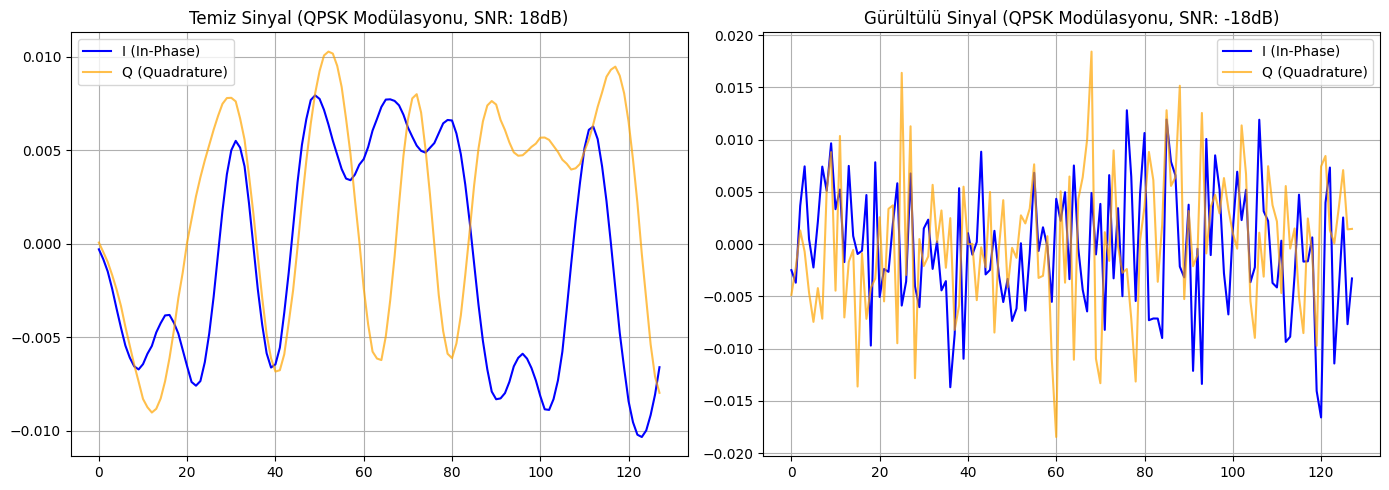

In [3]:
# KTR Raporu için Sinyal Karşılaştırma Görseli
mod_type = 'QPSK'  
high_snr = 18      # Çok temiz bir sinyal
low_snr = -18      # Çok gürültülü bir sinyal

# Verileri sözlükten çek
signal_high = Xd[(mod_type, high_snr)][0]
signal_low = Xd[(mod_type, low_snr)][0]

plt.figure(figsize=(14, 5))

# Yüksek SNR Çizimi (Temiz Sinyal)
plt.subplot(1, 2, 1)
plt.plot(signal_high[0], label='I (In-Phase)', color='blue')
plt.plot(signal_high[1], label='Q (Quadrature)', color='orange', alpha=0.7)
# .decode() fonksiyonunu da kaldırdık çünkü kelimemiz zaten normal metin.
plt.title(f'Temiz Sinyal ({mod_type} Modülasyonu, SNR: {high_snr}dB)') 
plt.legend()
plt.grid(True)

# Düşük SNR Çizimi (Gürültülü Sinyal)
plt.subplot(1, 2, 2)
plt.plot(signal_low[0], label='I (In-Phase)', color='blue')
plt.plot(signal_low[1], label='Q (Quadrature)', color='orange', alpha=0.7)
plt.title(f'Gürültülü Sinyal ({mod_type} Modülasyonu, SNR: {low_snr}dB)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [4]:
from tensorflow.keras.utils import to_categorical
import numpy as np

print("Veriler Yapay Zeka için hazırlanıyor (Bu işlem birkaç saniye sürebilir)...")

# Veriyi X (Girdi) ve Y (Etiket/Çıktı) olarak ayır
X = []
lbl = []
for mod in mods:
    for snr in snrs:
        X.append(Xd[(mod,snr)])
        for i in range(Xd[(mod,snr)].shape[0]):
            lbl.append((mod,snr))

# Listeleri NumPy dizisine çevir (Yapay zeka matrislerle çalışır)
X = np.vstack(X)
print(f"Toplam Girdi (X - Sinyaller) Boyutu: {X.shape}") 

# Etiketleri (QPSK, FM vs.) makinenin anlayacağı 0 ve 1'lere (One-Hot Encoding) çevir
def to_onehot(y):
    labels = list(map(lambda x: mods.index(y[x][0]), range(len(y))))
    return to_categorical(labels)

Y = to_onehot(lbl)
print(f"Toplam Etiket (Y - Cevaplar) Boyutu: {Y.shape}")

Veriler Yapay Zeka için hazırlanıyor (Bu işlem birkaç saniye sürebilir)...
Toplam Girdi (X - Sinyaller) Boyutu: (220000, 2, 128)
Toplam Etiket (Y - Cevaplar) Boyutu: (220000, 11)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense, Dropout, MaxPooling2D, Reshape
from tensorflow.keras.callbacks import EarlyStopping

print("CNN Modeli İnşa Ediliyor...")

# X verimizin (220000, 2, 128) olan boyutunu, CNN'in anlayacağı (220000, 1, 2, 128) formatına çeviriyoruz.
X_train_cnn = np.expand_dims(X, axis=1)

# Keras Modelini Başlat
model = Sequential()

# 1. Evrişim (Convolution) Katmanı: Sinyaldeki temel özellikleri (tepeler, çukurlar) bulur.
#model bu katmanda 64 farklı filtre kullanarak (1,3) boyutunda kaydırarak sinyali tarar. ReLU aktivasyon fonksiyonu, negatif değerleri sıfırlar ve pozitif değerleri olduğu gibi bırakır, böylece modelin daha karmaşık kalıpları öğrenmesine yardımcı olur. Padding 'same' olarak ayarlandığında, çıktı boyutu girişle aynı kalır, bu da kenar bilgilerini korur.
model.add(Conv2D(64, (1, 3), activation="relu", input_shape=(1, 2, 128), padding='same'))
model.add(Dropout(0.5)) # Modelin ezberlemesini önler yüzde 50 oranında rastgele nöronları kapatarak genelleme yeteneğini artırır.

# 2. Evrişim Katmanı: Daha karmaşık kalıpları öğrenir.
model.add(Conv2D(32, (1, 3), activation="relu", padding='same'))
model.add(Dropout(0.5))

# Veriyi düzleştirip karar mekanizmasına (Dense) aktarma
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Çıkış Katmanı: 11 farklı modülasyon tipi için 11 nöron.
# Softmax, her bir modülasyon için % ihtimal verir.
model.add(Dense(11, activation='softmax'))

# Modeli Derleme
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print("Model başarıyla derlendi! Eğitim başlıyor...")

# EarlyStopping: Eğer model öğrenmeyi durdurursa 50. turu (epoch) beklemeden erken keser.
# 'val_loss' izlenir, yani doğrulama setindeki kayıp değeri. Eğer bu değer 5 tur boyunca iyileşmezse, eğitim durdurulur ve en iyi ağırlıklar geri yüklenir.
erken_dur = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Eğitimi Başlat (Model %80 veriyi öğrenmek, %20'si doğrulama için kullanacak)
history = model.fit(
    X_train_cnn, Y,
    batch_size=1024,
    epochs=50,
    verbose=1,
    validation_split=0.2, # Verinin %20'sini doğrulama için ayır
    callbacks=[erken_dur]
)

print("\n--- EĞİTİM TAMAMLANDI! ---")

CNN Modeli İnşa Ediliyor...


c:\Users\habib\.conda\envs\teknofest_eh\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model başarıyla derlendi! Eğitim başlıyor...
Epoch 1/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.1580 - loss: 2.1723 - val_accuracy: 0.0000e+00 - val_loss: 6.5101
Epoch 2/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.2085 - loss: 2.0257 - val_accuracy: 0.0000e+00 - val_loss: 8.9067
Epoch 3/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.2430 - loss: 1.9760 - val_accuracy: 0.0000e+00 - val_loss: 11.1066
Epoch 4/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.2918 - loss: 1.8783 - val_accuracy: 0.0000e+00 - val_loss: 12.6564
Epoch 5/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.3223 - loss: 1.7849 - val_accuracy: 0.0000e+00 - val_loss: 13.5822
Epoch 6/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.3388 - loss: 1.7417 - val_accuracy: 0.0000e+00 - val_loss: 14.6028

--- EĞİTİM TAMAMLANDI! ---


In [6]:
from sklearn.model_selection import train_test_split

print("Veriler iskambil destesi gibi karıştırılıyor...")
# Veriyi iyice karıştırıp rastgele %80 Eğitim, %20 Test olarak bölelim
X_train, X_test, Y_train, Y_test = train_test_split(X_train_cnn, Y, test_size=0.2, random_state=42)

print("Yapay Zekanın hafızası sıfırlanıyor...")
# Modeli tekrar derleyelim ki eski kötü hafızasını unutsun
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

print("Gerçek eğitim başlıyor! Bu sefer biraz daha uzun sürebilir...")
history = model.fit(
    X_train, Y_train,
    batch_size=1024,
    epochs=50,
    verbose=1,
    validation_data=(X_test, Y_test), # Artık doğru ve karışık test verisini veriyoruz
    callbacks=[erken_dur]
)

Veriler iskambil destesi gibi karıştırılıyor...
Yapay Zekanın hafızası sıfırlanıyor...
Gerçek eğitim başlıyor! Bu sefer biraz daha uzun sürebilir...
Epoch 1/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.1555 - loss: 2.3166 - val_accuracy: 0.1821 - val_loss: 2.1680
Epoch 2/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.1725 - loss: 2.1752 - val_accuracy: 0.1874 - val_loss: 2.1241
Epoch 3/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.1867 - loss: 2.1267 - val_accuracy: 0.2570 - val_loss: 2.0208
Epoch 4/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.2411 - loss: 2.0123 - val_accuracy: 0.2797 - val_loss: 1.8900
Epoch 5/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.2607 - loss: 1.9461 - val_accuracy: 0.3034 - val_loss: 1.8466
Epoch 6/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.2697 - loss: 1.9160 - val_accuracy: 0.3104 - val_loss: 1.8278
Epoch 7/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.2770 - loss

Karmaşıklık Matrisi (Confusion Matrix) oluşturuluyor...
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


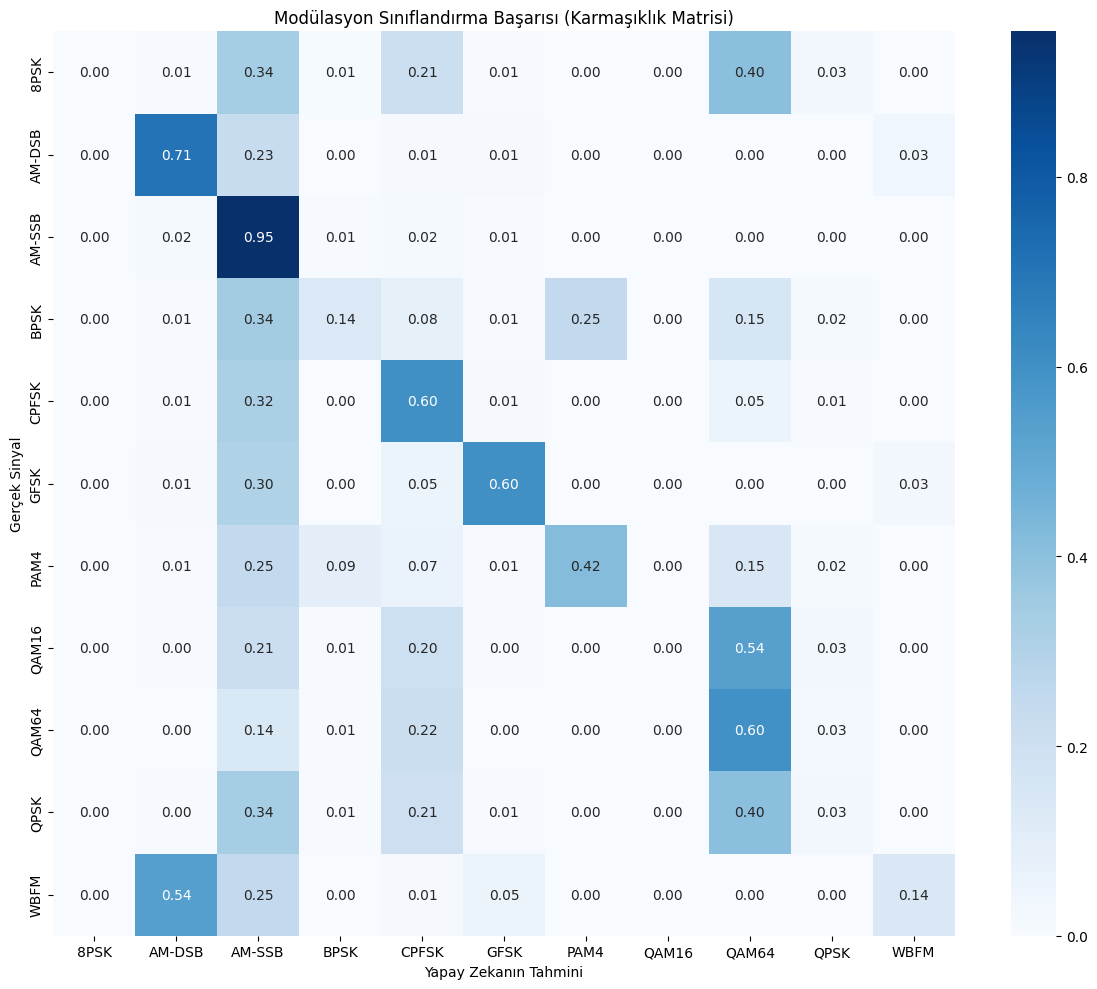

In [7]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

print("Karmaşıklık Matrisi (Confusion Matrix) oluşturuluyor...")

# Test verileri üzerinde modelin tahminlerini alalım
test_tahminleri = model.predict(X_test)

# Olasılıkları (0.9, 0.1 vb) kesin sonuçlara (örn: 'QPSK') çevirelim
gercek_degerler = np.argmax(Y_test, axis=1)
tahmin_edilenler = np.argmax(test_tahminleri, axis=1)

# Matrisi hesapla
cm = confusion_matrix(gercek_degerler, tahmin_edilenler)
# Matrisi yüzdelik oranlara çevir (Daha okunaklı olması için)
cm_yuzde = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Şık bir Isı Haritası (Heatmap) çiz
plt.figure(figsize=(12, 10))
sns.heatmap(cm_yuzde, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=mods, yticklabels=mods)

plt.title('Modülasyon Sınıflandırma Başarısı (Karmaşıklık Matrisi)')
plt.ylabel('Gerçek Sinyal')
plt.xlabel('Yapay Zekanın Tahmini')
plt.tight_layout()
plt.show()

In [8]:
# Şu anki "Genel Kültür" beynini sürüm 1 olarak kaydediyoruz.
model.save("teknofest_base_model_v1.h5")
print("Ana model başarıyla kaydedildi!")

Ana model başarıyla kaydedildi!


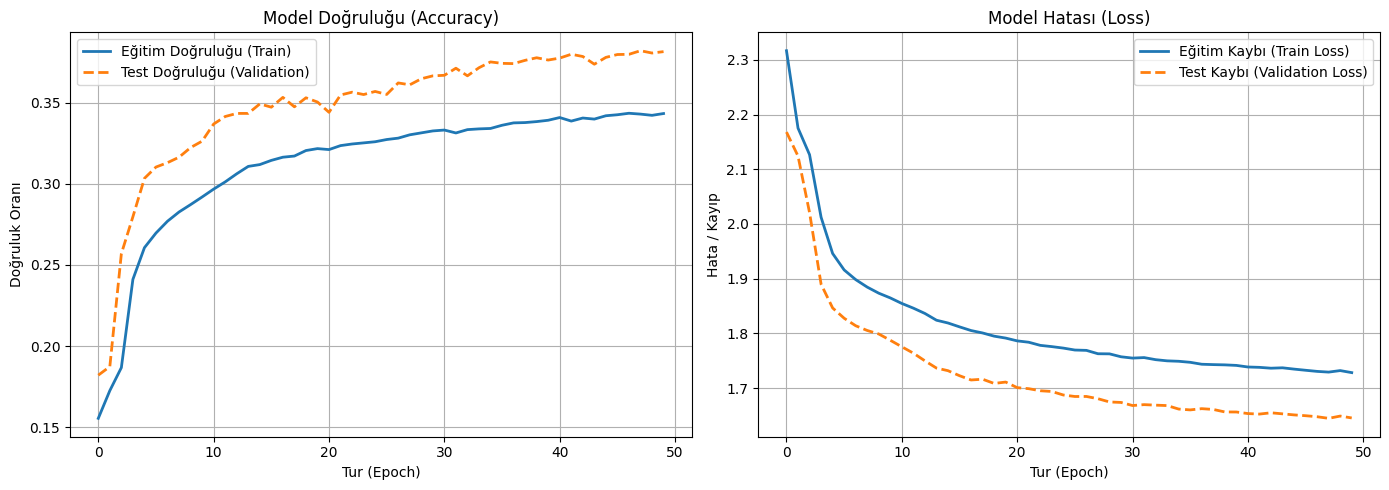

In [9]:
# 1. EĞİTİM VE KAYIP GRAFİKLERİ (Öğrenme Karnesi)
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Doğruluk (Accuracy) Grafiği
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Eğitim Doğruluğu (Train)', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Test Doğruluğu (Validation)', linewidth=2, linestyle='--')
plt.title('Model Doğruluğu (Accuracy)')
plt.ylabel('Doğruluk Oranı')
plt.xlabel('Tur (Epoch)')
plt.legend()
plt.grid(True)

# Kayıp (Loss) Grafiği
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Eğitim Kaybı (Train Loss)', linewidth=2)
plt.plot(history.history['val_loss'], label='Test Kaybı (Validation Loss)', linewidth=2, linestyle='--')
plt.title('Model Hatası (Loss)')
plt.ylabel('Hata / Kayıp')
plt.xlabel('Tur (Epoch)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [10]:
# 2. DETAYLI SINIFLANDIRMA RAPORU
from sklearn.metrics import classification_report

print("\n--- AKADEMİK SINIFLANDIRMA RAPORU ---\n")
# gercek_degerler ve tahmin_edilenler değişkenlerini zaten üstteki hücrede hesaplamıştın
rapor = classification_report(gercek_degerler, tahmin_edilenler, target_names=mods)
print(rapor)


--- AKADEMİK SINIFLANDIRMA RAPORU ---

              precision    recall  f1-score   support

        8PSK       0.00      0.00      0.00      3937
      AM-DSB       0.54      0.71      0.61      4062
      AM-SSB       0.26      0.95      0.40      3914
        BPSK       0.51      0.14      0.21      3990
       CPFSK       0.36      0.60      0.45      4063
        GFSK       0.84      0.60      0.70      3975
        PAM4       0.62      0.42      0.50      3977
       QAM16       0.00      0.00      0.00      3864
       QAM64       0.27      0.60      0.37      4162
        QPSK       0.20      0.03      0.05      4049
        WBFM       0.66      0.14      0.23      4007

    accuracy                           0.38     44000
   macro avg       0.39      0.38      0.32     44000
weighted avg       0.39      0.38      0.32     44000



SNR bazlı doğruluk oranları hesaplanıyor...


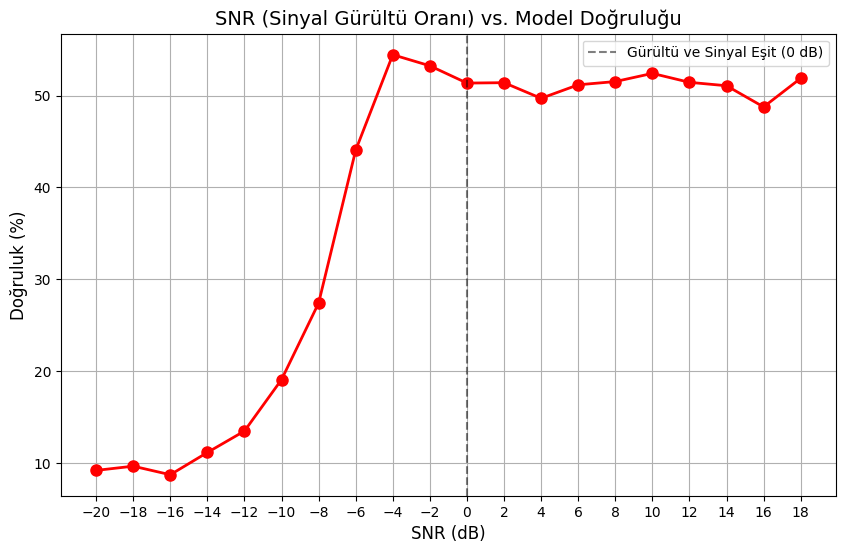

In [11]:
# 3. SİNYAL/GÜRÜLTÜ ORANI (SNR) - DOĞRULUK GRAFİĞİ
print("SNR bazlı doğruluk oranları hesaplanıyor...")

# Çok önemli bir veri bilimi hilesi: 
# Train_test_split yaparken random_state=42 kullandığın için, 
# aynı state ile böldüğümüzde test setindeki sinyallerin SNR değerlerini eşleştirebiliriz!
_, _, _, _, _, lbl_test = train_test_split(X_train_cnn, Y, lbl, test_size=0.2, random_state=42)
snr_test = [x[1] for x in lbl_test]

# Her bir SNR değeri için doğruluk oranını tutacağımız liste
snr_accuracy = []

for snr_val in snrs:
    # Sadece o anki SNR değerine sahip olan test verilerinin indekslerini bul
    snr_mask = np.array(snr_test) == snr_val
    
    # O SNR'a ait gerçek ve tahmin edilen değerleri filtrele
    y_gercek_snr = gercek_degerler[snr_mask]
    y_tahmin_snr = tahmin_edilenler[snr_mask]
    
    # Doğruluk oranını hesapla
    dogru_sayisi = np.sum(y_gercek_snr == y_tahmin_snr)
    toplam_sayi = len(y_gercek_snr)
    
    if toplam_sayi > 0:
        accuracy = dogru_sayisi / toplam_sayi
        snr_accuracy.append(accuracy * 100)
    else:
        snr_accuracy.append(0)

# Grafiği Çizdir
plt.figure(figsize=(10, 6))
plt.plot(snrs, snr_accuracy, marker='o', linestyle='-', color='r', linewidth=2, markersize=8)
plt.title('SNR (Sinyal Gürültü Oranı) vs. Model Doğruluğu', fontsize=14)
plt.xlabel('SNR (dB)', fontsize=12)
plt.ylabel('Doğruluk (%)', fontsize=12)
plt.grid(True)
plt.xticks(snrs)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.5, label='Gürültü ve Sinyal Eşit (0 dB)')
plt.legend()
plt.show()

In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

Y_pred = model_v3.predict(X_test_v3)
y_pred = np.argmax(Y_pred, axis=1)
y_true = np.argmax(Y_test_v3, axis=1)

print(classification_report(y_true, y_pred))
print(confusion_matrix(y_true, y_pred))

1032/1032 ━━━━━━━━━━━━━━━━━━━━ 25s 24ms/step
              precision    recall  f1-score   support

           0       0.05      0.01      0.01      2895
           1       0.51      0.34      0.41      2924
           2       0.53      0.27      0.35      3064
           3       0.17      0.06      0.09      3000
           4       0.23      0.39      0.29      3032
           5       0.33      0.57      0.42      2942
           6       0.49      0.49      0.49      3035
           7       0.19      0.06      0.10      3040
           8       0.23      0.73      0.35      3060
           9       0.15      0.06      0.09      3017
          10       0.47      0.45      0.46      2991

    accuracy                           0.31     33000
   macro avg       0.30      0.31      0.28     33000
weighted avg       0.30      0.31      0.28     33000

[[  16    6  119  105  470  254   76  135 1552  158    4]
 [   7  995   77   39   76  345    9    5    4   26 1341]
 [  24   23  816  102  696

In [17]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, LSTM, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split

print("--- AŞAMA 4: SNR FİLTRESİ (Gürültülü Çöpleri Ayıklama) ---")
temiz_X = []
temiz_lbl = []

for mod in mods:
    for snr in snrs:
        if snr >= -10: 
            temiz_X.append(Xd[(mod,snr)])
            for i in range(Xd[(mod,snr)].shape[0]):
                temiz_lbl.append((mod,snr))

temiz_X = np.vstack(temiz_X)
temiz_Y = to_onehot(temiz_lbl)
print(f"Filtrelenmiş Temiz Veri Boyutu: {temiz_X.shape}")

print("--- AŞAMA 1: FEATURE ENGINEERING (Genlik ve Faz Çıkarma) ---")
I = temiz_X[:, 0, :]
Q = temiz_X[:, 1, :]

Amplitude = np.sqrt(I**2 + Q**2)
Phase = np.arctan2(Q, I)

X_features = np.stack([I, Q, Amplitude, Phase], axis=2)
print(f"Yapay Zekanın Yeni Besini (I, Q, Amp, Phase): {X_features.shape}")

print("--- AŞAMA 1.5: KUSURSUZ AKADEMİK BÖLÜNME (Train / Val / Test) ---")
# 1. Önce veriyi %80 Eğitim, %20 Geçici (Validation + Test) olarak böl
X_train_v3, X_temp, Y_train_v3, Y_temp = train_test_split(X_features, temiz_Y, test_size=0.2, random_state=42)

# 2. Sonra o %20'lik Geçici veriyi tam ortadan ikiye böl (%10 Val, %10 Test)
X_val_v3, X_test_v3, Y_val_v3, Y_test_v3 = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

print(f"Eğitim Seti (Train): {X_train_v3.shape[0]} sinyal")
print(f"Doğrulama Seti (Validation): {X_val_v3.shape[0]} sinyal")
print(f"Test Seti (Test): {X_test_v3.shape[0]} sinyal (Hocaya sunulacak SAF veri)")

print("--- AŞAMA 2 & 5: DAHA BÜYÜK CNN + LSTM MİMARİSİ ---")
model_v3 = Sequential()

model_v3.add(Conv1D(filters=128, kernel_size=3, input_shape=(128, 4)))
model_v3.add(BatchNormalization())
model_v3.add(Activation('relu'))
model_v3.add(Dropout(0.3))

model_v3.add(Conv1D(filters=64, kernel_size=3))
model_v3.add(BatchNormalization())
model_v3.add(Activation('relu'))
model_v3.add(Dropout(0.3))

model_v3.add(LSTM(128, return_sequences=False)) 
model_v3.add(Dropout(0.4))

model_v3.add(Dense(128, activation='relu'))
model_v3.add(Dropout(0.4))
model_v3.add(Dense(11, activation='softmax'))

model_v3.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

print("--- AŞAMA 3: LR SCHEDULER VE EĞİTİM ---")
lr_dusur = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001, verbose=1)
# Early Stopping artık TEST verisine değil, sadece VAL verisine bakıyor!
erken_dur = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

history_v3 = model_v3.fit(
    X_train_v3, Y_train_v3,
    batch_size=1024,
    epochs=60,
    verbose=1,
    validation_data=(X_val_v3, Y_val_v3), # <DÜZELTME BURADA
    callbacks=[erken_dur, lr_dusur]
)

model_v3.save("teknofest_ultimate_model_v3.h5")
print("\n--- TEKNİK ŞAHESER V3 KAYDEDİLDİ! ---")

--- AŞAMA 4: SNR FİLTRESİ (Gürültülü Çöpleri Ayıklama) ---
Filtrelenmiş Temiz Veri Boyutu: (165000, 2, 128)
--- AŞAMA 1: FEATURE ENGINEERING (Genlik ve Faz Çıkarma) ---
Yapay Zekanın Yeni Besini (I, Q, Amp, Phase): (165000, 128, 4)
--- AŞAMA 1.5: KUSURSUZ AKADEMİK BÖLÜNME (Train / Val / Test) ---
Eğitim Seti (Train): 132000 sinyal
Doğrulama Seti (Validation): 16500 sinyal
Test Seti (Test): 16500 sinyal (Hocaya sunulacak SAF veri)
--- AŞAMA 2 & 5: DAHA BÜYÜK CNN + LSTM MİMARİSİ ---
--- AŞAMA 3: LR SCHEDULER VE EĞİTİM ---


c:\Users\habib\.conda\envs\teknofest_eh\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/60
129/129 ━━━━━━━━━━━━━━━━━━━━ 218s 2s/step - accuracy: 0.2512 - loss: 1.9980 - val_accuracy: 0.2012 - val_loss: 2.5532 - learning_rate: 0.0010
Epoch 2/60
129/129 ━━━━━━━━━━━━━━━━━━━━ 208s 2s/step - accuracy: 0.3970 - loss: 1.5217 - val_accuracy: 0.3406 - val_loss: 1.9316 - learning_rate: 0.0010
Epoch 3/60
129/129 ━━━━━━━━━━━━━━━━━━━━ 200s 2s/step - accuracy: 0.4502 - loss: 1.3228 - val_accuracy: 0.4858 - val_loss: 1.2272 - learning_rate: 0.0010
Epoch 4/60
129/129 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.4809 - loss: 1.2041 - val_accuracy: 0.4936 - val_loss: 1.1903 - learning_rate: 0.0010
Epoch 5/60
129/129 ━━━━━━━━━━━━━━━━━━━━ 1723s 13s/step - accuracy: 0.4847 - loss: 1.1969 - val_accuracy: 0.4972 - val_loss: 1.1300 - learning_rate: 0.0010
Epoch 6/60
129/129 ━━━━━━━━━━━━━━━━━━━━ 212s 2s/step - accuracy: 0.4967 - loss: 1.1501 - val_accuracy: 0.5018 - val_loss: 1.1620 - learning_rate: 0.0010
Epoch 7/60
129/129 ━━━━━━━━━━━━━━━━━━━━ 217s 2s/step - accuracy: 0.5003 - loss: 


--- TEKNİK ŞAHESER V3 KAYDEDİLDİ! ---


In [18]:
test_loss, test_acc = model_v3.evaluate(X_test_v3, Y_test_v3, verbose=1)

print("Saf Test Loss:", test_loss)
print("Saf Test Accuracy:", test_acc)

516/516 ━━━━━━━━━━━━━━━━━━━━ 16s 30ms/step - accuracy: 0.7196 - loss: 0.6348
Saf Test Loss: 0.6347907781600952
Saf Test Accuracy: 0.7195757627487183


In [19]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

Y_pred = model_v3.predict(X_test_v3)

y_pred = np.argmax(Y_pred, axis=1)
y_true = np.argmax(Y_test_v3, axis=1)

print(classification_report(y_true, y_pred))
print(confusion_matrix(y_true, y_pred))

516/516 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step
              precision    recall  f1-score   support

           0       0.72      0.68      0.70      1396
           1       0.58      0.93      0.72      1462
           2       0.60      0.95      0.73      1519
           3       0.89      0.80      0.84      1510
           4       0.88      0.83      0.86      1498
           5       0.88      0.86      0.87      1426
           6       0.95      0.92      0.93      1552
           7       0.47      0.07      0.12      1570
           8       0.52      0.92      0.67      1512
           9       0.79      0.68      0.73      1542
          10       0.88      0.31      0.46      1513

    accuracy                           0.72     16500
   macro avg       0.74      0.72      0.69     16500
weighted avg       0.74      0.72      0.69     16500

[[ 943   10  168   24   42    7    4   28    5  165    0]
 [   1 1364   46    0    0   16    1    0    0    0   34]
 [   0   15 1448   12    8  

In [20]:
print(model_v3.summary())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 126, 128)       │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 126, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 126, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 126, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 124, 64)        │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 124, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 124, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 124, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 430,691 (1.64 MB)

 Trainable params: 143,435 (560.29 KB)

 Non-trainable params: 384 (1.50 KB)

 Optimizer params: 286,872 (1.09 MB)

None


In [21]:
print(mods)

['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']


In [22]:
target_names = list(mods)

print(classification_report(
    y_true,
    y_pred,
    target_names=target_names
))

              precision    recall  f1-score   support

        8PSK       0.72      0.68      0.70      1396
      AM-DSB       0.58      0.93      0.72      1462
      AM-SSB       0.60      0.95      0.73      1519
        BPSK       0.89      0.80      0.84      1510
       CPFSK       0.88      0.83      0.86      1498
        GFSK       0.88      0.86      0.87      1426
        PAM4       0.95      0.92      0.93      1552
       QAM16       0.47      0.07      0.12      1570
       QAM64       0.52      0.92      0.67      1512
        QPSK       0.79      0.68      0.73      1542
        WBFM       0.88      0.31      0.46      1513

    accuracy                           0.72     16500
   macro avg       0.74      0.72      0.69     16500
weighted avg       0.74      0.72      0.69     16500



<Figure size 1000x1000 with 0 Axes>

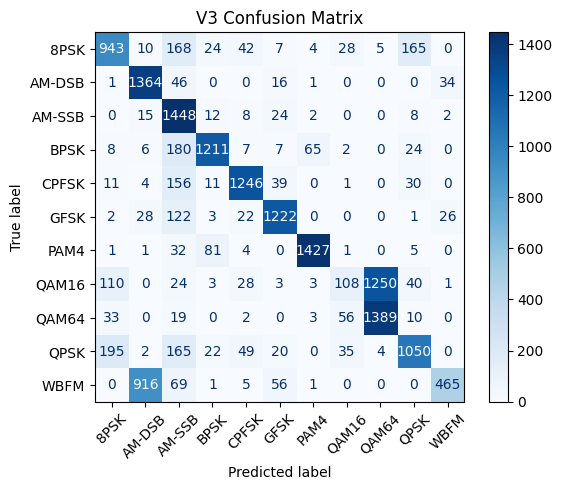

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=mods
)

plt.figure(figsize=(10, 10))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("V3 Confusion Matrix")
plt.show()

--- 1. ÖĞRENME EĞRİLERİ (Eğitim Karnesi) ---


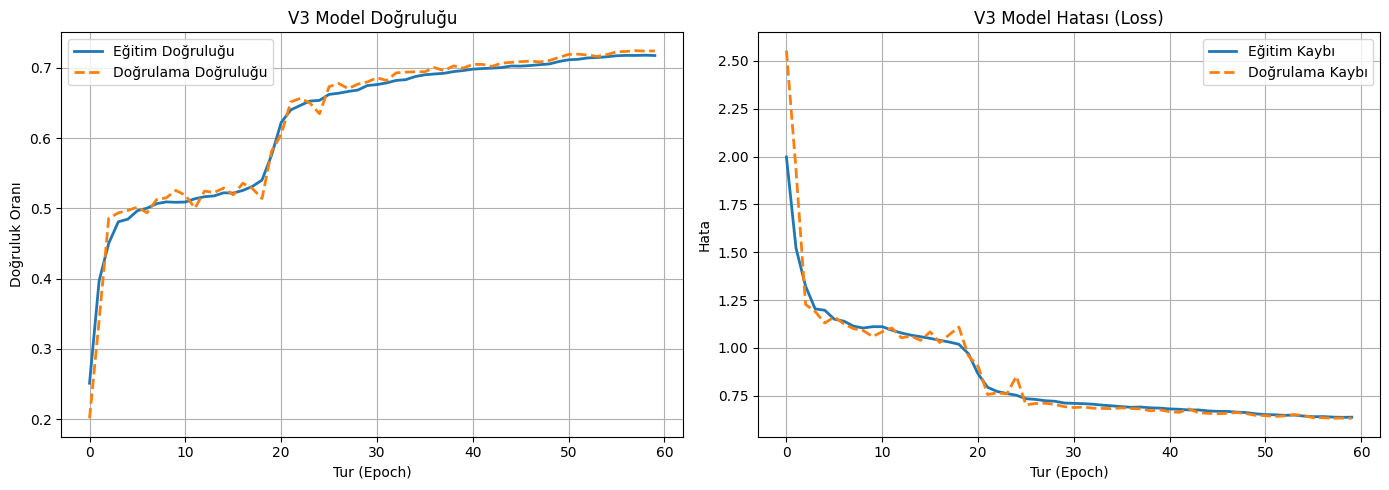


--- 2. TEST SETİ İLE AKADEMİK ÇIKARIM (SIFIR VERİ SIZINTISI) ---
516/516 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step

--- SINIFLANDIRMA RAPORU ---
              precision    recall  f1-score   support

        8PSK       0.72      0.68      0.70      1396
      AM-DSB       0.58      0.93      0.72      1462
      AM-SSB       0.60      0.95      0.73      1519
        BPSK       0.89      0.80      0.84      1510
       CPFSK       0.88      0.83      0.86      1498
        GFSK       0.88      0.86      0.87      1426
        PAM4       0.95      0.92      0.93      1552
       QAM16       0.47      0.07      0.12      1570
       QAM64       0.52      0.92      0.67      1512
        QPSK       0.79      0.68      0.73      1542
        WBFM       0.88      0.31      0.46      1513

    accuracy                           0.72     16500
   macro avg       0.74      0.72      0.69     16500
weighted avg       0.74      0.72      0.69     16500


--- 3. KARMAŞIKLIK MATRİSİ (Confusion Matrix) -

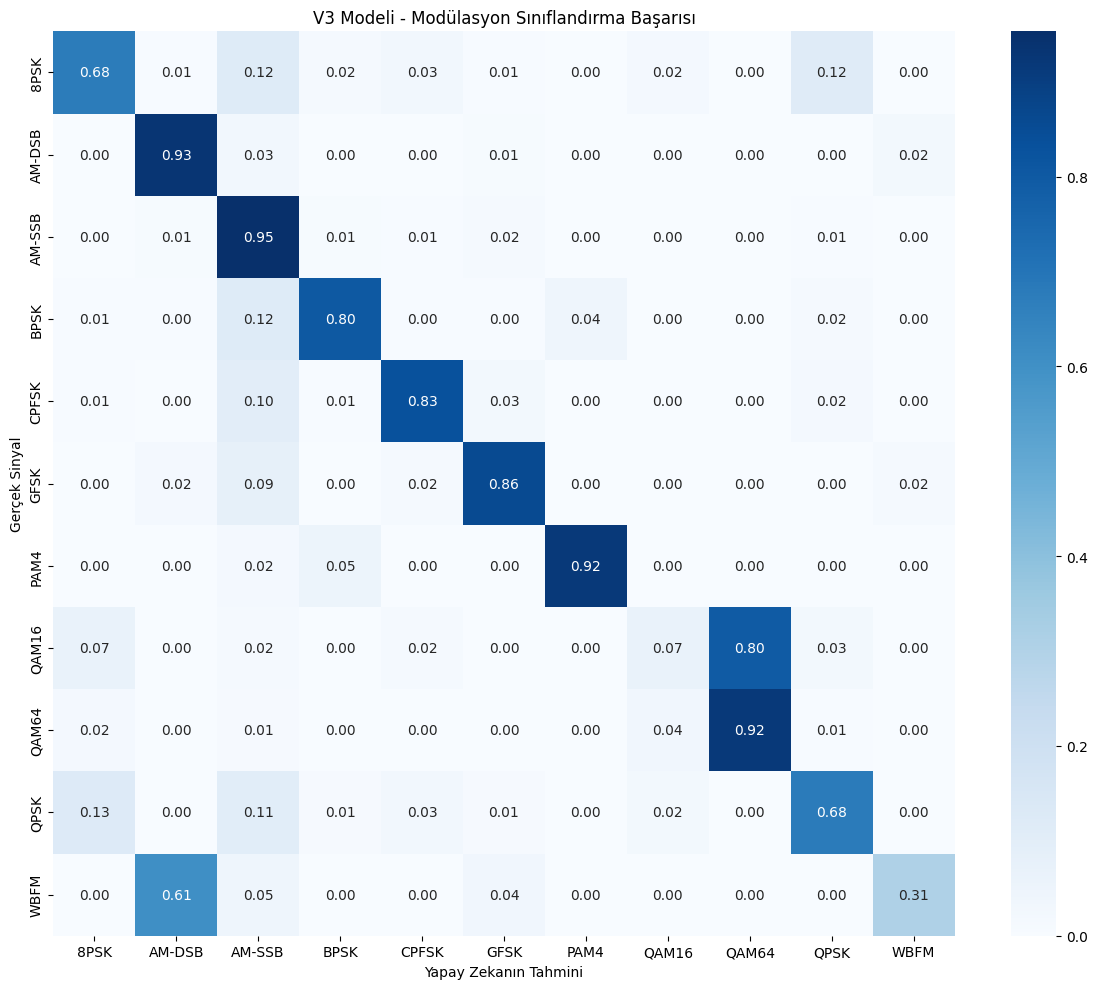

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("--- 1. ÖĞRENME EĞRİLERİ (Eğitim Karnesi) ---")
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_v3.history['accuracy'], label='Eğitim Doğruluğu', linewidth=2)
plt.plot(history_v3.history['val_accuracy'], label='Doğrulama Doğruluğu', linewidth=2, linestyle='--')
plt.title('V3 Model Doğruluğu')
plt.ylabel('Doğruluk Oranı')
plt.xlabel('Tur (Epoch)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_v3.history['loss'], label='Eğitim Kaybı', linewidth=2)
plt.plot(history_v3.history['val_loss'], label='Doğrulama Kaybı', linewidth=2, linestyle='--')
plt.title('V3 Model Hatası (Loss)')
plt.ylabel('Hata')
plt.xlabel('Tur (Epoch)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\n--- 2. TEST SETİ İLE AKADEMİK ÇIKARIM (SIFIR VERİ SIZINTISI) ---")
# Modelin hayatında hiç görmediği X_test_v3 verisiyle sınav yapıyoruz
test_tahminleri = model_v3.predict(X_test_v3)

gercek_degerler = np.argmax(Y_test_v3, axis=1)
tahmin_edilenler = np.argmax(test_tahminleri, axis=1)

print("\n--- SINIFLANDIRMA RAPORU ---")
print(classification_report(gercek_degerler, tahmin_edilenler, target_names=mods))

print("\n--- 3. KARMAŞIKLIK MATRİSİ (Confusion Matrix) ---")
cm = confusion_matrix(gercek_degerler, tahmin_edilenler)
cm_yuzde = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(cm_yuzde, annot=True, fmt=".2f", cmap="Blues", xticklabels=mods, yticklabels=mods)
plt.title('V3 Modeli - Modülasyon Sınıflandırma Başarısı')
plt.ylabel('Gerçek Sinyal')
plt.xlabel('Yapay Zekanın Tahmini')
plt.tight_layout()
plt.show()

In [25]:
import numpy as np
from sklearn.model_selection import train_test_split

print("--- V4 AŞAMA 1: SNR FİLTRESİ ---")

temiz_X = []
temiz_lbl = []

for mod in mods:
    for snr in snrs:
        if snr >= -10:
            temiz_X.append(Xd[(mod, snr)])
            for i in range(Xd[(mod, snr)].shape[0]):
                temiz_lbl.append((mod, snr))

temiz_X = np.vstack(temiz_X)
temiz_Y = to_onehot(temiz_lbl)

print("temiz_X:", temiz_X.shape)
print("temiz_Y:", temiz_Y.shape)

print("--- V4 AŞAMA 2: FEATURE ENGINEERING ---")

I = temiz_X[:, 0, :]
Q = temiz_X[:, 1, :]

Amplitude = np.sqrt(I**2 + Q**2)
Phase = np.arctan2(Q, I)

phase_sin = np.sin(Phase)
phase_cos = np.cos(Phase)

# V3: I, Q, Amplitude, Phase idi.
# V4: I, Q, Amplitude, sin(Phase), cos(Phase)
X_features_v4 = np.stack(
    [I, Q, Amplitude, phase_sin, phase_cos],
    axis=2
)

print("X_features_v4:", X_features_v4.shape)

--- V4 AŞAMA 1: SNR FİLTRESİ ---
temiz_X: (165000, 2, 128)
temiz_Y: (165000, 11)
--- V4 AŞAMA 2: FEATURE ENGINEERING ---
X_features_v4: (165000, 128, 5)


In [26]:
print("--- V4 AŞAMA 3: STRATIFIED TRAIN / VAL / TEST SPLIT ---")

labels_int = np.argmax(temiz_Y, axis=1)

X_train_v4, X_temp_v4, Y_train_v4, Y_temp_v4 = train_test_split(
    X_features_v4,
    temiz_Y,
    test_size=0.2,
    random_state=42,
    stratify=labels_int
)

temp_labels_int = np.argmax(Y_temp_v4, axis=1)

X_val_v4, X_test_v4, Y_val_v4, Y_test_v4 = train_test_split(
    X_temp_v4,
    Y_temp_v4,
    test_size=0.5,
    random_state=42,
    stratify=temp_labels_int
)

print("Train:", X_train_v4.shape)
print("Val:", X_val_v4.shape)
print("Test:", X_test_v4.shape)

--- V4 AŞAMA 3: STRATIFIED TRAIN / VAL / TEST SPLIT ---
Train: (132000, 128, 5)
Val: (16500, 128, 5)
Test: (16500, 128, 5)


In [27]:
print("--- V4 AŞAMA 4: NORMALIZATION ---")

mean_v4 = X_train_v4.mean(axis=(0, 1), keepdims=True)
std_v4 = X_train_v4.std(axis=(0, 1), keepdims=True) + 1e-8

X_train_v4 = (X_train_v4 - mean_v4) / std_v4
X_val_v4 = (X_val_v4 - mean_v4) / std_v4
X_test_v4 = (X_test_v4 - mean_v4) / std_v4

print("Normalization tamamlandı.")

--- V4 AŞAMA 4: NORMALIZATION ---
Normalization tamamlandı.


In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, LSTM, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print("--- V4 AŞAMA 5: MODEL MİMARİSİ ---")

model_v4 = Sequential()

model_v4.add(Conv1D(filters=128, kernel_size=5, padding="same", input_shape=(128, 5)))
model_v4.add(BatchNormalization())
model_v4.add(Activation("relu"))
model_v4.add(Dropout(0.25))

model_v4.add(Conv1D(filters=128, kernel_size=5, padding="same"))
model_v4.add(BatchNormalization())
model_v4.add(Activation("relu"))
model_v4.add(Dropout(0.25))

model_v4.add(Conv1D(filters=64, kernel_size=3, padding="same"))
model_v4.add(BatchNormalization())
model_v4.add(Activation("relu"))
model_v4.add(Dropout(0.25))

model_v4.add(LSTM(128, return_sequences=False))
model_v4.add(Dropout(0.35))

model_v4.add(Dense(128, activation="relu"))
model_v4.add(Dropout(0.35))

model_v4.add(Dense(11, activation="softmax"))

model_v4.compile(
    loss="categorical_crossentropy",
    optimizer=Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

model_v4.summary()

--- V4 AŞAMA 5: MODEL MİMARİSİ ---


c:\Users\habib\.conda\envs\teknofest_eh\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 128, 128)       │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 128, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 128, 64)        │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 228,043 (890.79 KB)

 Trainable params: 227,403 (888.29 KB)

 Non-trainable params: 640 (2.50 KB)

In [29]:
print("--- V4 AŞAMA 6: EĞİTİM ---")

lr_dusur_v4 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-5,
    verbose=1
)

erken_dur_v4 = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

history_v4 = model_v4.fit(
    X_train_v4,
    Y_train_v4,
    batch_size=512,
    epochs=70,
    validation_data=(X_val_v4, Y_val_v4),
    callbacks=[erken_dur_v4, lr_dusur_v4],
    verbose=1
)

model_v4.save("teknofest_model_v4.keras")
print("--- V4 MODEL KAYDEDİLDİ ---")

--- V4 AŞAMA 6: EĞİTİM ---
Epoch 1/70
258/258 ━━━━━━━━━━━━━━━━━━━━ 289s 1s/step - accuracy: 0.4457 - loss: 1.4426 - val_accuracy: 0.4105 - val_loss: 1.8276 - learning_rate: 0.0010
Epoch 2/70
258/258 ━━━━━━━━━━━━━━━━━━━━ 286s 1s/step - accuracy: 0.5994 - loss: 0.9423 - val_accuracy: 0.6376 - val_loss: 0.8769 - learning_rate: 0.0010
Epoch 3/70
258/258 ━━━━━━━━━━━━━━━━━━━━ 279s 1s/step - accuracy: 0.6360 - loss: 0.8399 - val_accuracy: 0.6655 - val_loss: 0.7637 - learning_rate: 0.0010
Epoch 4/70
258/258 ━━━━━━━━━━━━━━━━━━━━ 320s 1s/step - accuracy: 0.6556 - loss: 0.7999 - val_accuracy: 0.6796 - val_loss: 0.7548 - learning_rate: 0.0010
Epoch 5/70
258/258 ━━━━━━━━━━━━━━━━━━━━ 864s 3s/step - accuracy: 0.6725 - loss: 0.7624 - val_accuracy: 0.6902 - val_loss: 0.7197 - learning_rate: 0.0010
Epoch 6/70
258/258 ━━━━━━━━━━━━━━━━━━━━ 290s 1s/step - accuracy: 0.6845 - loss: 0.7352 - val_accuracy: 0.6999 - val_loss: 0.6930 - learning_rate: 0.0010
Epoch 7/70
258/258 ━━━━━━━━━━━━━━━━━━━━ 3065s 12s/step 

In [30]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

print("--- V4 SAF TEST DEĞERLENDİRMESİ ---")

test_loss_v4, test_acc_v4 = model_v4.evaluate(X_test_v4, Y_test_v4, verbose=1)

print("V4 Test Loss:", test_loss_v4)
print("V4 Test Accuracy:", test_acc_v4)

Y_pred_v4 = model_v4.predict(X_test_v4)
y_pred_v4 = np.argmax(Y_pred_v4, axis=1)
y_true_v4 = np.argmax(Y_test_v4, axis=1)

print("\n--- SINIF SIRASI ---")
for i, mod in enumerate(mods):
    print(i, mod)

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(
    y_true_v4,
    y_pred_v4,
    target_names=mods
))

print("\n--- CONFUSION MATRIX ---")
print(confusion_matrix(y_true_v4, y_pred_v4))

--- V4 SAF TEST DEĞERLENDİRMESİ ---
516/516 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.7927 - loss: 0.5216
V4 Test Loss: 0.5215857625007629
V4 Test Accuracy: 0.7927272915840149
516/516 ━━━━━━━━━━━━━━━━━━━━ 19s 36ms/step

--- SINIF SIRASI ---
0 8PSK
1 AM-DSB
2 AM-SSB
3 BPSK
4 CPFSK
5 GFSK
6 PAM4
7 QAM16
8 QAM64
9 QPSK
10 WBFM

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

        8PSK       0.82      0.76      0.79      1500
      AM-DSB       0.60      0.93      0.73      1500
      AM-SSB       0.60      0.97      0.74      1500
        BPSK       0.92      0.79      0.85      1500
       CPFSK       0.90      0.83      0.86      1500
        GFSK       0.89      0.87      0.88      1500
        PAM4       0.92      0.94      0.93      1500
       QAM16       0.74      0.81      0.77      1500
       QAM64       0.88      0.75      0.81      1500
        QPSK       0.92      0.73      0.82      1500
        WBFM       0.88      0.33      0.

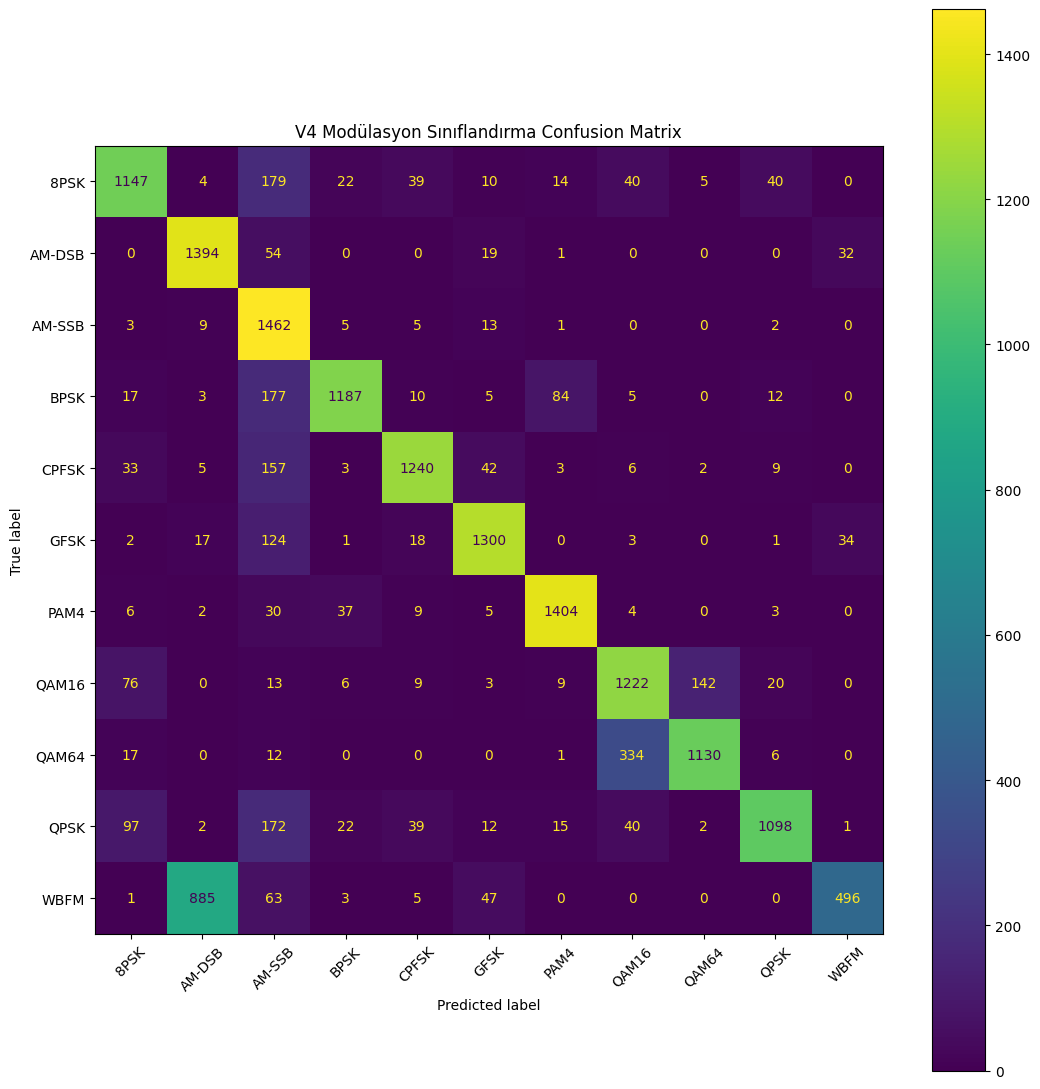

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm_v4 = confusion_matrix(y_true_v4, y_pred_v4)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_v4,
    display_labels=mods
)

fig, ax = plt.subplots(figsize=(11, 11))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("V4 Modülasyon Sınıflandırma Confusion Matrix")
plt.tight_layout()
plt.show()

In [32]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import numpy as np

report_dict_v4 = classification_report(
    y_true_v4,
    y_pred_v4,
    target_names=mods,
    output_dict=True,
    zero_division=0
)

report_df_v4 = pd.DataFrame(report_dict_v4).transpose()
print(report_df_v4)

report_df_v4.to_csv("v4_classification_report.csv", index=True)

cm_v4 = confusion_matrix(y_true_v4, y_pred_v4)
cm_df_v4 = pd.DataFrame(cm_v4, index=mods, columns=mods)
cm_df_v4.to_csv("v4_confusion_matrix.csv", index=True)

print("Raporlar kaydedildi:")
print("v4_classification_report.csv")
print("v4_confusion_matrix.csv")


              precision    recall  f1-score       support
8PSK           0.819871  0.764667  0.791307   1500.000000
AM-DSB         0.600603  0.929333  0.729652   1500.000000
AM-SSB         0.598445  0.974667  0.741567   1500.000000
BPSK           0.923017  0.791333  0.852118   1500.000000
CPFSK          0.902475  0.826667  0.862909   1500.000000
GFSK           0.892857  0.866667  0.879567   1500.000000
PAM4           0.916449  0.936000  0.926121   1500.000000
QAM16          0.738815  0.814667  0.774889   1500.000000
QAM64          0.882123  0.753333  0.812657   1500.000000
QPSK           0.921914  0.732000  0.816054   1500.000000
WBFM           0.880995  0.330667  0.480853   1500.000000
accuracy       0.792727  0.792727  0.792727      0.792727
macro avg      0.825233  0.792727  0.787972  16500.000000
weighted avg   0.825233  0.792727  0.787972  16500.000000
Raporlar kaydedildi:
v4_classification_report.csv
v4_confusion_matrix.csv


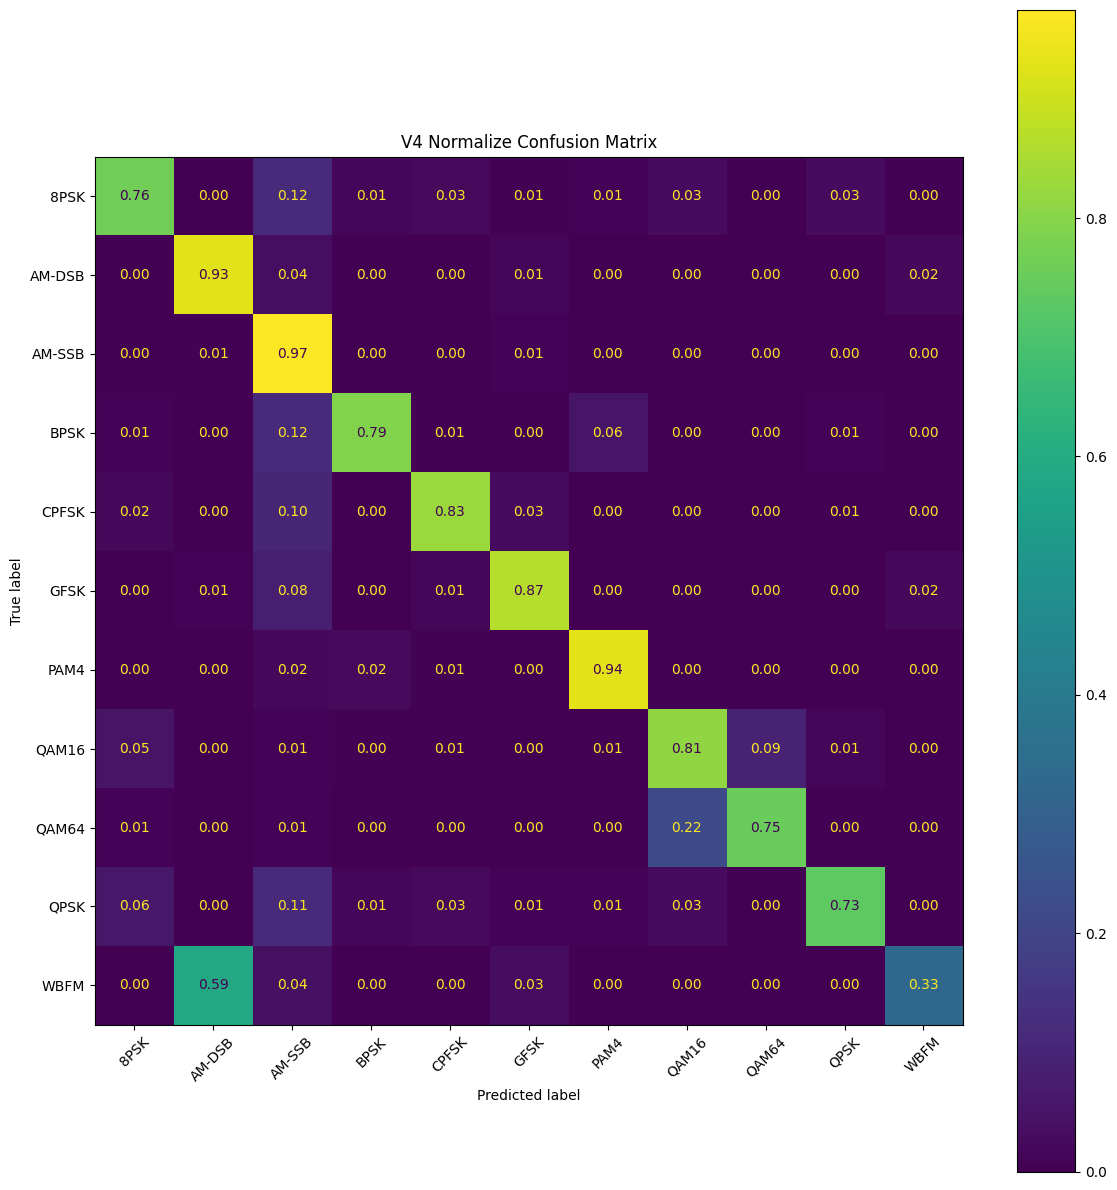

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm_norm_v4 = confusion_matrix(
    y_true_v4,
    y_pred_v4,
    normalize="true"
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm_v4,
    display_labels=mods
)

fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, xticks_rotation=45, values_format=".2f")
plt.title("V4 Normalize Confusion Matrix")
plt.tight_layout()
plt.savefig("v4_normalized_confusion_matrix.png", dpi=300)
plt.show()

In [34]:
cm_df_v4 = pd.DataFrame(cm_v4, index=mods, columns=mods)

for mod in mods:
    row = cm_df_v4.loc[mod].copy()
    correct = row[mod]
    row[mod] = 0
    print(f"\nGerçek sınıf: {mod}")
    print(f"Doğru tahmin: {correct}")
    print("En çok karıştığı sınıflar:")
    print(row.sort_values(ascending=False).head(3))


Gerçek sınıf: 8PSK
Doğru tahmin: 1147
En çok karıştığı sınıflar:
AM-SSB    179
QAM16      40
QPSK       40
Name: 8PSK, dtype: int64

Gerçek sınıf: AM-DSB
Doğru tahmin: 1394
En çok karıştığı sınıflar:
AM-SSB    54
WBFM      32
GFSK      19
Name: AM-DSB, dtype: int64

Gerçek sınıf: AM-SSB
Doğru tahmin: 1462
En çok karıştığı sınıflar:
GFSK      13
AM-DSB     9
BPSK       5
Name: AM-SSB, dtype: int64

Gerçek sınıf: BPSK
Doğru tahmin: 1187
En çok karıştığı sınıflar:
AM-SSB    177
PAM4       84
8PSK       17
Name: BPSK, dtype: int64

Gerçek sınıf: CPFSK
Doğru tahmin: 1240
En çok karıştığı sınıflar:
AM-SSB    157
GFSK       42
8PSK       33
Name: CPFSK, dtype: int64

Gerçek sınıf: GFSK
Doğru tahmin: 1300
En çok karıştığı sınıflar:
AM-SSB    124
WBFM       34
CPFSK      18
Name: GFSK, dtype: int64

Gerçek sınıf: PAM4
Doğru tahmin: 1404
En çok karıştığı sınıflar:
BPSK      37
AM-SSB    30
CPFSK      9
Name: PAM4, dtype: int64

Gerçek sınıf: QAM16
Doğru tahmin: 1222
En çok karıştığı sınıflar:
Q

In [35]:
print("--- V5 FEATURE ENGINEERING ---")

I = temiz_X[:, 0, :]
Q = temiz_X[:, 1, :]

Amplitude = np.sqrt(I**2 + Q**2)

Phase = np.arctan2(Q, I)
Phase_sin = np.sin(Phase)
Phase_cos = np.cos(Phase)

Phase_unwrapped = np.unwrap(Phase, axis=1)
Inst_Freq = np.diff(
    Phase_unwrapped,
    axis=1,
    prepend=Phase_unwrapped[:, :1]
)

Amp_Diff = np.diff(
    Amplitude,
    axis=1,
    prepend=Amplitude[:, :1]
)

X_features_v5 = np.stack(
    [
        I,
        Q,
        Amplitude,
        Phase_sin,
        Phase_cos,
        Inst_Freq,
        Amp_Diff
    ],
    axis=2
)

print("V5 giriş boyutu:", X_features_v5.shape)

--- V5 FEATURE ENGINEERING ---
V5 giriş boyutu: (165000, 128, 7)


In [36]:
from sklearn.model_selection import train_test_split

X_train_v5, X_temp_v5, Y_train_v5, Y_temp_v5 = train_test_split(
    X_features_v5,
    temiz_Y,
    test_size=0.2,
    random_state=42,
    stratify=np.argmax(temiz_Y, axis=1)
)

X_val_v5, X_test_v5, Y_val_v5, Y_test_v5 = train_test_split(
    X_temp_v5,
    Y_temp_v5,
    test_size=0.5,
    random_state=42,
    stratify=np.argmax(Y_temp_v5, axis=1)
)

mean_v5 = X_train_v5.mean(axis=(0, 1), keepdims=True)
std_v5 = X_train_v5.std(axis=(0, 1), keepdims=True) + 1e-8

X_train_v5 = (X_train_v5 - mean_v5) / std_v5
X_val_v5 = (X_val_v5 - mean_v5) / std_v5
X_test_v5 = (X_test_v5 - mean_v5) / std_v5

In [37]:
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, LSTM, Dense, Dropout, BatchNormalization, Activation, MaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt

In [38]:
print("--- V5 AŞAMA 1: FEATURE ENGINEERING ---")

I = temiz_X[:, 0, :]
Q = temiz_X[:, 1, :]

Amplitude = np.sqrt(I**2 + Q**2)

Phase = np.arctan2(Q, I)
Phase_sin = np.sin(Phase)
Phase_cos = np.cos(Phase)

# FM türleri için önemli: faz değişimi / anlık frekans bilgisi
Phase_unwrapped = np.unwrap(Phase, axis=1)

Inst_Freq = np.diff(
    Phase_unwrapped,
    axis=1,
    prepend=Phase_unwrapped[:, :1]
)

# AM türleri için önemli: genlik değişimi
Amp_Diff = np.diff(
    Amplitude,
    axis=1,
    prepend=Amplitude[:, :1]
)

X_features_v5 = np.stack(
    [
        I,
        Q,
        Amplitude,
        Phase_sin,
        Phase_cos,
        Inst_Freq,
        Amp_Diff
    ],
    axis=2
).astype(np.float32)

print("V5 giriş boyutu:", X_features_v5.shape)
print("V5 özellikleri: I, Q, Amplitude, sin(Phase), cos(Phase), Inst_Freq, Amp_Diff")

--- V5 AŞAMA 1: FEATURE ENGINEERING ---
V5 giriş boyutu: (165000, 128, 7)
V5 özellikleri: I, Q, Amplitude, sin(Phase), cos(Phase), Inst_Freq, Amp_Diff


In [39]:
print("--- V5 AŞAMA 2: TRAIN / VAL / TEST SPLIT ---")

y_labels = np.argmax(temiz_Y, axis=1)

X_train_v5, X_temp_v5, Y_train_v5, Y_temp_v5 = train_test_split(
    X_features_v5,
    temiz_Y,
    test_size=0.2,
    random_state=42,
    stratify=y_labels
)

y_temp_labels = np.argmax(Y_temp_v5, axis=1)

X_val_v5, X_test_v5, Y_val_v5, Y_test_v5 = train_test_split(
    X_temp_v5,
    Y_temp_v5,
    test_size=0.5,
    random_state=42,
    stratify=y_temp_labels
)

print("Train:", X_train_v5.shape, Y_train_v5.shape)
print("Val:", X_val_v5.shape, Y_val_v5.shape)
print("Test:", X_test_v5.shape, Y_test_v5.shape)

--- V5 AŞAMA 2: TRAIN / VAL / TEST SPLIT ---
Train: (132000, 128, 7) (132000, 11)
Val: (16500, 128, 7) (16500, 11)
Test: (16500, 128, 7) (16500, 11)


In [40]:
print("--- V5 AŞAMA 3: NORMALİZASYON ---")

mean_v5 = X_train_v5.mean(axis=(0, 1), keepdims=True)
std_v5 = X_train_v5.std(axis=(0, 1), keepdims=True) + 1e-8

X_train_v5 = (X_train_v5 - mean_v5) / std_v5
X_val_v5 = (X_val_v5 - mean_v5) / std_v5
X_test_v5 = (X_test_v5 - mean_v5) / std_v5

np.save("v5_feature_mean.npy", mean_v5)
np.save("v5_feature_std.npy", std_v5)

print("Normalizasyon tamamlandı.")
print("Mean kaydedildi: v5_feature_mean.npy")
print("Std kaydedildi: v5_feature_std.npy")

--- V5 AŞAMA 3: NORMALİZASYON ---
Normalizasyon tamamlandı.
Mean kaydedildi: v5_feature_mean.npy
Std kaydedildi: v5_feature_std.npy


In [41]:
print("--- V5 AŞAMA 4: MODEL MİMARİSİ ---")

num_classes = temiz_Y.shape[1]

model_v5 = Sequential()

model_v5.add(Conv1D(
    filters=128,
    kernel_size=5,
    padding="same",
    input_shape=(128, 7)
))
model_v5.add(BatchNormalization())
model_v5.add(Activation("relu"))
model_v5.add(Dropout(0.25))

model_v5.add(Conv1D(
    filters=128,
    kernel_size=3,
    padding="same"
))
model_v5.add(BatchNormalization())
model_v5.add(Activation("relu"))
model_v5.add(MaxPooling1D(pool_size=2))
model_v5.add(Dropout(0.30))

model_v5.add(Conv1D(
    filters=64,
    kernel_size=3,
    padding="same"
))
model_v5.add(BatchNormalization())
model_v5.add(Activation("relu"))
model_v5.add(Dropout(0.30))

model_v5.add(LSTM(128, return_sequences=False))
model_v5.add(Dropout(0.40))

model_v5.add(Dense(128, activation="relu"))
model_v5.add(Dropout(0.40))

model_v5.add(Dense(num_classes, activation="softmax"))

model_v5.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_v5.summary()

--- V5 AŞAMA 4: MODEL MİMARİSİ ---


c:\Users\habib\.conda\envs\teknofest_eh\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_9 (Conv1D)               │ (None, 128, 128)       │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 128, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 64, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 196,555 (767.79 KB)

 Trainable params: 195,915 (765.29 KB)

 Non-trainable params: 640 (2.50 KB)

In [42]:
print("--- V5 AŞAMA 5: EĞİTİM ---")

lr_dusur_v5 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-5,
    verbose=1
)

erken_dur_v5 = EarlyStopping(
    monitor="val_loss",
    patience=9,
    restore_best_weights=True,
    verbose=1
)

checkpoint_v5 = ModelCheckpoint(
    "teknofest_model_v5_best.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

history_v5 = model_v5.fit(
    X_train_v5,
    Y_train_v5,
    batch_size=512,
    epochs=80,
    validation_data=(X_val_v5, Y_val_v5),
    callbacks=[erken_dur_v5, lr_dusur_v5, checkpoint_v5],
    verbose=1
)

model_v5.save("teknofest_model_v5_final.keras")

print("--- V5 MODEL KAYDEDİLDİ ---")

--- V5 AŞAMA 5: EĞİTİM ---
Epoch 1/80
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 785ms/step - accuracy: 0.3726 - loss: 1.6722
Epoch 1: val_loss improved from None to 1.74626, saving model to teknofest_model_v5_best.keras

Epoch 1: finished saving model to teknofest_model_v5_best.keras
258/258 ━━━━━━━━━━━━━━━━━━━━ 215s 813ms/step - accuracy: 0.4847 - loss: 1.3183 - val_accuracy: 0.4564 - val_loss: 1.7463 - learning_rate: 0.0010
Epoch 2/80
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 767ms/step - accuracy: 0.5991 - loss: 0.9361
Epoch 2: val_loss improved from 1.74626 to 0.82103, saving model to teknofest_model_v5_best.keras

Epoch 2: finished saving model to teknofest_model_v5_best.keras
258/258 ━━━━━━━━━━━━━━━━━━━━ 205s 793ms/step - accuracy: 0.6101 - loss: 0.9081 - val_accuracy: 0.6396 - val_loss: 0.8210 - learning_rate: 0.0010
Epoch 3/80
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 695ms/step - accuracy: 0.6302 - loss: 0.8531
Epoch 3: val_loss improved from 0.82103 to 0.78416, saving model to teknofest_model_v5_best.kera

In [43]:
print("--- V5 SAF TEST DEĞERLENDİRMESİ ---")

test_loss_v5, test_acc_v5 = model_v5.evaluate(
    X_test_v5,
    Y_test_v5,
    verbose=1
)

print("V5 Test Loss:", test_loss_v5)
print("V5 Test Accuracy:", test_acc_v5)

Y_pred_v5 = model_v5.predict(X_test_v5)
y_pred_v5 = np.argmax(Y_pred_v5, axis=1)
y_true_v5 = np.argmax(Y_test_v5, axis=1)

print("\n--- SINIF SIRASI ---")
for i, mod in enumerate(mods):
    print(i, mod)

print("\n--- V5 CLASSIFICATION REPORT ---")
print(classification_report(
    y_true_v5,
    y_pred_v5,
    target_names=mods,
    zero_division=0
))

--- V5 SAF TEST DEĞERLENDİRMESİ ---
516/516 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.7960 - loss: 0.5120
V5 Test Loss: 0.5120115280151367
V5 Test Accuracy: 0.7960000038146973
516/516 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step

--- SINIF SIRASI ---
0 8PSK
1 AM-DSB
2 AM-SSB
3 BPSK
4 CPFSK
5 GFSK
6 PAM4
7 QAM16
8 QAM64
9 QPSK
10 WBFM

--- V5 CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

        8PSK       0.86      0.74      0.80      1500
      AM-DSB       0.58      0.95      0.72      1500
      AM-SSB       0.61      0.96      0.75      1500
        BPSK       0.88      0.84      0.86      1500
       CPFSK       0.89      0.84      0.86      1500
        GFSK       0.89      0.87      0.88      1500
        PAM4       0.96      0.91      0.94      1500
       QAM16       0.80      0.77      0.79      1500
       QAM64       0.87      0.81      0.84      1500
        QPSK       0.86      0.76      0.80      1500
        WBFM       0.87      0.31     

In [7]:
import pandas as pd

v4_report = pd.read_csv("v4_classification_report.csv", index_col=0)
v5_report = pd.read_csv("v5_classification_report.csv", index_col=0)

important_classes = ["AM-DSB", "AM-SSB", "WBFM", "CPFSK", "GFSK"]

comparison = pd.DataFrame({
    "V4_precision": v4_report.loc[important_classes, "precision"],
    "V4_recall": v4_report.loc[important_classes, "recall"],
    "V4_f1": v4_report.loc[important_classes, "f1-score"],
    "V5_precision": v5_report.loc[important_classes, "precision"],
    "V5_recall": v5_report.loc[important_classes, "recall"],
    "V5_f1": v5_report.loc[important_classes, "f1-score"],
})

comparison["recall_change"] = comparison["V5_recall"] - comparison["V4_recall"]
comparison["f1_change"] = comparison["V5_f1"] - comparison["V4_f1"]

print(comparison)

        V4_precision  V4_recall     V4_f1  V5_precision  V5_recall     V5_f1  \
AM-DSB      0.600603   0.929333  0.729652      0.584672   0.946000  0.722689   
AM-SSB      0.598445   0.974667  0.741567      0.614726   0.957333  0.748697   
WBFM        0.880995   0.330667  0.480853      0.872180   0.309333  0.456693   
CPFSK       0.902475   0.826667  0.862909      0.887870   0.839333  0.862920   
GFSK        0.892857   0.866667  0.879567      0.891096   0.867333  0.879054   

        recall_change  f1_change  
AM-DSB       0.016667  -0.006963  
AM-SSB      -0.017333   0.007129  
WBFM        -0.021333  -0.024160  
CPFSK        0.012667   0.000011  
GFSK         0.000667  -0.000513  


In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import numpy as np

print("--- V5 RAPORLARI KAYDEDİLİYOR ---")

# Eğer y_true_v5 / y_pred_v5 zaten varsa direkt kullanır.
# Yoksa yeniden tahmin alır.
Y_pred_v5 = model_v5.predict(X_test_v5)
y_pred_v5 = np.argmax(Y_pred_v5, axis=1)
y_true_v5 = np.argmax(Y_test_v5, axis=1)

report_dict_v5 = classification_report(
    y_true_v5,
    y_pred_v5,
    target_names=mods,
    output_dict=True,
    zero_division=0
)

report_df_v5 = pd.DataFrame(report_dict_v5).transpose()
report_df_v5.to_csv("v5_classification_report.csv", index=True)

cm_v5 = confusion_matrix(y_true_v5, y_pred_v5)
cm_df_v5 = pd.DataFrame(cm_v5, index=mods, columns=mods)
cm_df_v5.to_csv("v5_confusion_matrix.csv", index=True)

print("Kaydedildi:")
print("v5_classification_report.csv")
print("v5_confusion_matrix.csv")

print(report_df_v5)

--- V5 RAPORLARI KAYDEDİLİYOR ---


NameError: name 'model_v5' is not defined

In [46]:
v4_report = pd.read_csv("v4_classification_report.csv", index_col=0)
v5_report = pd.read_csv("v5_classification_report.csv", index_col=0)

important_classes = ["AM-DSB", "AM-SSB", "WBFM", "CPFSK", "GFSK"]

comparison = pd.DataFrame({
    "V4_precision": v4_report.loc[important_classes, "precision"],
    "V4_recall": v4_report.loc[important_classes, "recall"],
    "V4_f1": v4_report.loc[important_classes, "f1-score"],
    "V5_precision": v5_report.loc[important_classes, "precision"],
    "V5_recall": v5_report.loc[important_classes, "recall"],
    "V5_f1": v5_report.loc[important_classes, "f1-score"],
})

comparison["recall_change"] = comparison["V5_recall"] - comparison["V4_recall"]
comparison["f1_change"] = comparison["V5_f1"] - comparison["V4_f1"]

print(comparison)

        V4_precision  V4_recall     V4_f1  V5_precision  V5_recall     V5_f1  \
AM-DSB      0.600603   0.929333  0.729652      0.584672   0.946000  0.722689   
AM-SSB      0.598445   0.974667  0.741567      0.614726   0.957333  0.748697   
WBFM        0.880995   0.330667  0.480853      0.872180   0.309333  0.456693   
CPFSK       0.902475   0.826667  0.862909      0.887870   0.839333  0.862920   
GFSK        0.892857   0.866667  0.879567      0.891096   0.867333  0.879054   

        recall_change  f1_change  
AM-DSB       0.016667  -0.006963  
AM-SSB      -0.017333   0.007129  
WBFM        -0.021333  -0.024160  
CPFSK        0.012667   0.000011  
GFSK         0.000667  -0.000513  


In [47]:
v5_cm = pd.read_csv("v5_confusion_matrix.csv", index_col=0)

print("--- V5 WBFM HATA ANALİZİ ---")
v5_wbfm = v5_cm.loc["WBFM"].copy()
print(v5_wbfm.sort_values(ascending=False).head(6))

--- V5 WBFM HATA ANALİZİ ---
AM-DSB    940
WBFM      464
GFSK       47
AM-SSB     44
BPSK        2
8PSK        1
Name: WBFM, dtype: int64


In [48]:
v5_cm = pd.read_csv("v5_confusion_matrix.csv", index_col=0)

print("--- V5 GFSK HATA ANALİZİ ---")
v5_gfsk = v5_cm.loc["GFSK"].copy()
print(v5_gfsk.sort_values(ascending=False).head(6))

--- V5 GFSK HATA ANALİZİ ---
GFSK      1301
AM-SSB     113
WBFM        35
CPFSK       25
AM-DSB      21
BPSK         3
Name: GFSK, dtype: int64


In [3]:
v5_cm = pd.read_csv("v5_confusion_matrix.csv", index_col=0)

print("--- V5 CPFSK HATA ANALİZİ ---")
v5_cpfsk = v5_cm.loc["CPFSK"].copy()
print(v5_cpfsk.sort_values(ascending=False).head(6))

NameError: name 'pd' is not defined

In [9]:
import pickle
import numpy as np
import pandas as pd

from tensorflow.keras.models import load_model
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
with open("RML2016.10a_dict.pkl", "rb") as f:
    Xd = pickle.load(f, encoding="latin1")

snrs = sorted(list(set([k[1] for k in Xd.keys()])))
mods = sorted(list(set([k[0] for k in Xd.keys()])))

print("Modülasyonlar:", mods)
print("SNR seviyeleri:", snrs)

C:\Users\habib\AppData\Local\Temp\ipykernel_19976\2724614982.py:2: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  Xd = pickle.load(f, encoding="latin1")


Modülasyonlar: ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']
SNR seviyeleri: [-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18]


In [12]:
def to_onehot(y):
    labels = list(map(lambda x: mods.index(y[x][0]), range(len(y))))
    return to_categorical(labels, num_classes=len(mods))

In [13]:
temiz_X = []
temiz_lbl = []

for mod in mods:
    for snr in snrs:
        if snr >= -10:
            temiz_X.append(Xd[(mod, snr)])
            for i in range(Xd[(mod, snr)].shape[0]):
                temiz_lbl.append((mod, snr))

temiz_X = np.vstack(temiz_X)
temiz_Y = to_onehot(temiz_lbl)

print("temiz_X:", temiz_X.shape)
print("temiz_Y:", temiz_Y.shape)

temiz_X: (165000, 2, 128)
temiz_Y: (165000, 11)


In [14]:
I = temiz_X[:, 0, :]
Q = temiz_X[:, 1, :]

Amplitude = np.sqrt(I**2 + Q**2)

Phase = np.arctan2(Q, I)
Phase_sin = np.sin(Phase)
Phase_cos = np.cos(Phase)

Phase_unwrapped = np.unwrap(Phase, axis=1)

Inst_Freq = np.diff(
    Phase_unwrapped,
    axis=1,
    prepend=Phase_unwrapped[:, :1]
)

Amp_Diff = np.diff(
    Amplitude,
    axis=1,
    prepend=Amplitude[:, :1]
)

X_features_v5 = np.stack(
    [
        I,
        Q,
        Amplitude,
        Phase_sin,
        Phase_cos,
        Inst_Freq,
        Amp_Diff
    ],
    axis=2
)

print("X_features_v5:", X_features_v5.shape)

X_features_v5: (165000, 128, 7)


In [15]:
X_train_v5, X_temp_v5, Y_train_v5, Y_temp_v5 = train_test_split(
    X_features_v5,
    temiz_Y,
    test_size=0.2,
    random_state=42,
    stratify=np.argmax(temiz_Y, axis=1)
)

X_val_v5, X_test_v5, Y_val_v5, Y_test_v5 = train_test_split(
    X_temp_v5,
    Y_temp_v5,
    test_size=0.5,
    random_state=42,
    stratify=np.argmax(Y_temp_v5, axis=1)
)

print("Train:", X_train_v5.shape)
print("Val:", X_val_v5.shape)
print("Test:", X_test_v5.shape)

Train: (132000, 128, 7)
Val: (16500, 128, 7)
Test: (16500, 128, 7)


In [16]:
mean_v5 = np.load("v5_feature_mean.npy")
std_v5 = np.load("v5_feature_std.npy")

In [17]:
X_train_v5 = (X_train_v5 - mean_v5) / std_v5
X_val_v5 = (X_val_v5 - mean_v5) / std_v5
X_test_v5 = (X_test_v5 - mean_v5) / std_v5

In [18]:
model_v5 = load_model("teknofest_model_v5_best.keras")

In [19]:
test_loss_v5, test_acc_v5 = model_v5.evaluate(
    X_test_v5,
    Y_test_v5,
    verbose=1
)

print("V5 Test Loss:", test_loss_v5)
print("V5 Test Accuracy:", test_acc_v5)

516/516 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.7960 - loss: 0.5120
V5 Test Loss: 0.5120115280151367
V5 Test Accuracy: 0.7960000038146973


In [20]:
Y_pred_v5 = model_v5.predict(X_test_v5)

y_pred_v5 = np.argmax(Y_pred_v5, axis=1)
y_true_v5 = np.argmax(Y_test_v5, axis=1)

report_dict_v5 = classification_report(
    y_true_v5,
    y_pred_v5,
    target_names=mods,
    output_dict=True,
    zero_division=0
)

report_df_v5 = pd.DataFrame(report_dict_v5).transpose()
report_df_v5.to_csv("v5_classification_report.csv", index=True)

cm_v5 = confusion_matrix(y_true_v5, y_pred_v5)
cm_df_v5 = pd.DataFrame(cm_v5, index=mods, columns=mods)
cm_df_v5.to_csv("v5_confusion_matrix.csv", index=True)

print("Kaydedildi:")
print("v5_classification_report.csv")
print("v5_confusion_matrix.csv")

print(report_df_v5)

516/516 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step
Kaydedildi:
v5_classification_report.csv
v5_confusion_matrix.csv
              precision    recall  f1-score    support
8PSK           0.857252  0.744667  0.797003   1500.000
AM-DSB         0.584672  0.946000  0.722689   1500.000
AM-SSB         0.614726  0.957333  0.748697   1500.000
BPSK           0.875348  0.838000  0.856267   1500.000
CPFSK          0.887870  0.839333  0.862920   1500.000
GFSK           0.891096  0.867333  0.879054   1500.000
PAM4           0.962676  0.911333  0.936301   1500.000
QAM16          0.804031  0.771333  0.787343   1500.000
QAM64          0.870714  0.812667  0.840690   1500.000
QPSK           0.856283  0.758667  0.804525   1500.000
WBFM           0.872180  0.309333  0.456693   1500.000
accuracy       0.796000  0.796000  0.796000      0.796
macro avg      0.825168  0.796000  0.790198  16500.000
weighted avg   0.825168  0.796000  0.790198  16500.000


--- V5 CONFUSION MATRIX ÇİZİLİYOR ---


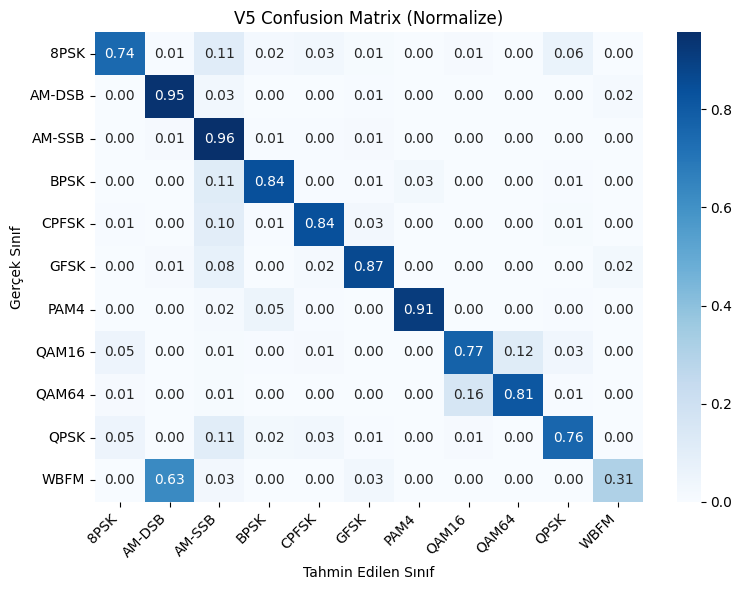

Kaydedildi: v5_confusion_matrix_normalized.png


In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("--- V5 CONFUSION MATRIX ÇİZİLİYOR ---")

# Eğer bunlar zaten varsa direkt kullanır
# Yoksa yeniden üretir
# y_true_v5 = np.argmax(Y_test_v5, axis=1)
# y_pred_v5 = np.argmax(model_v5.predict(X_test_v5), axis=1)

cm_v5 = confusion_matrix(y_true_v5, y_pred_v5)

# Satır bazlı normalize et (her gerçek sınıf kendi içinde % olsun)
cm_v5_norm = cm_v5.astype("float") / cm_v5.sum(axis=1, keepdims=True)

# DataFrame yapalım, daha okunaklı olur
cm_v5_df = pd.DataFrame(cm_v5, index=mods, columns=mods)
cm_v5_norm_df = pd.DataFrame(cm_v5_norm, index=mods, columns=mods)

# --- Normalized heatmap ---
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_v5_norm_df,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=mods,
    yticklabels=mods
)

plt.title("V5 Confusion Matrix (Normalize)")
plt.xlabel("Tahmin Edilen Sınıf")
plt.ylabel("Gerçek Sınıf")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("v5_confusion_matrix_normalized.png", dpi=300, bbox_inches="tight")
plt.show()

print("Kaydedildi: v5_confusion_matrix_normalized.png")

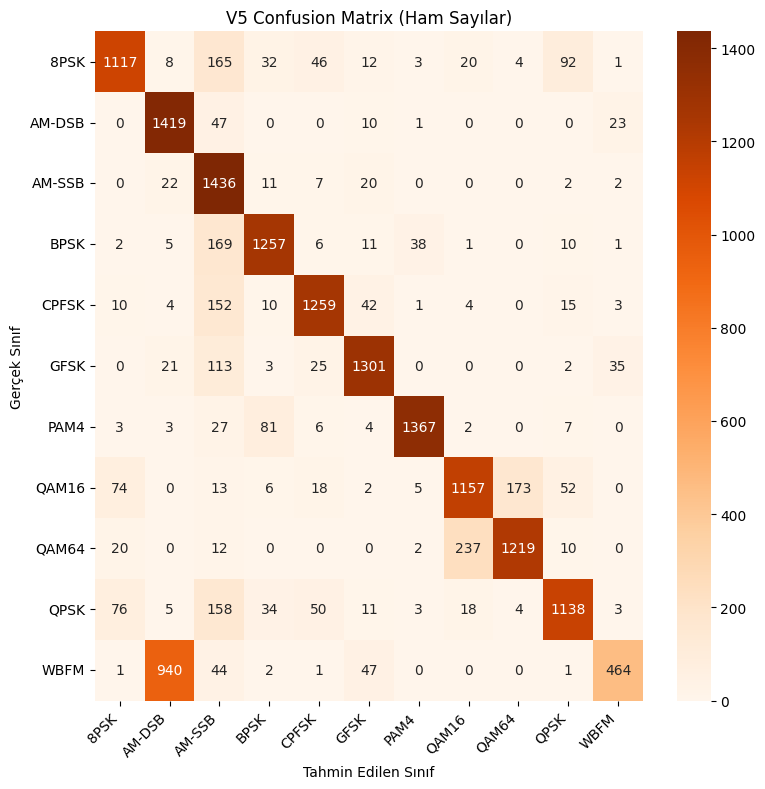

Kaydedildi: v5_confusion_matrix_counts.png


In [27]:
plt.figure(figsize=(8, 8))
sns.heatmap(
    cm_v5_df,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=mods,
    yticklabels=mods
)

plt.title("V5 Confusion Matrix (Ham Sayılar)")
plt.xlabel("Tahmin Edilen Sınıf")
plt.ylabel("Gerçek Sınıf")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("v5_confusion_matrix_counts.png", dpi=300, bbox_inches="tight")
plt.show()

print("Kaydedildi: v5_confusion_matrix_counts.png")

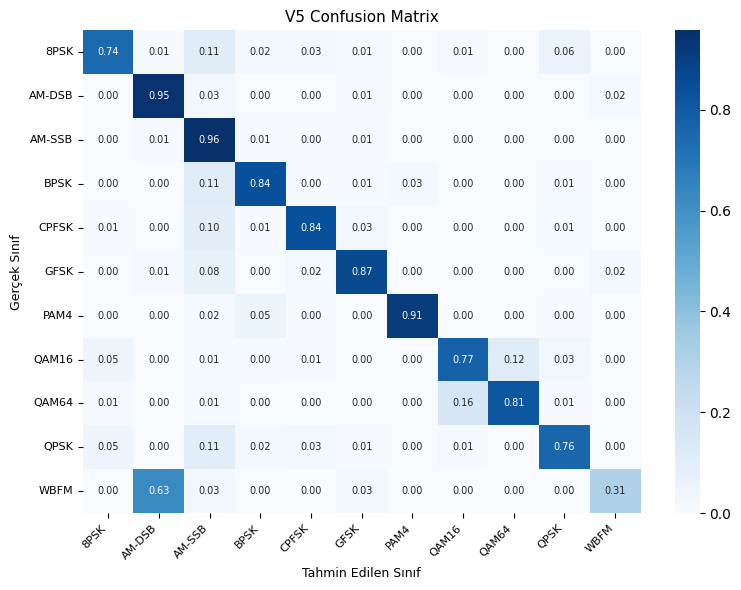

In [24]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_v5_norm_df,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=mods,
    yticklabels=mods,
    annot_kws={"size": 7}
)

plt.title("V5 Confusion Matrix", fontsize=11)
plt.xlabel("Tahmin Edilen Sınıf", fontsize=9)
plt.ylabel("Gerçek Sınıf", fontsize=9)

plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

In [28]:
X_train_v5, X_temp_v5, Y_train_v5, Y_temp_v5, lbl_train_v5, lbl_temp_v5 = train_test_split(
    X_features_v5,
    temiz_Y,
    temiz_lbl,
    test_size=0.2,
    random_state=42,
    stratify=np.argmax(temiz_Y, axis=1)
)

X_val_v5, X_test_v5, Y_val_v5, Y_test_v5, lbl_val_v5, lbl_test_v5 = train_test_split(
    X_temp_v5,
    Y_temp_v5,
    lbl_temp_v5,
    test_size=0.5,
    random_state=42,
    stratify=np.argmax(Y_temp_v5, axis=1)
)

--- V5 SNR BAZLI WBFM ANALİZİ ---
Test seti: (16500, 128, 7)
Test label sayısı: 16500
516/516 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step
Test setindeki WBFM örnek sayısı: 1500

--- WBFM SNR BAZLI BAŞARI ---
    SNR  WBFM_Total  WBFM_Correct  WBFM_Accuracy Most_Predicted_Class  \
0   -10         106             7       0.066038               AM-DSB   
1    -8         106             9       0.084906               AM-DSB   
2    -6         102            14       0.137255               AM-DSB   
3    -4          87            18       0.206897               AM-DSB   
4    -2          99            23       0.232323               AM-DSB   
5     0          90            35       0.388889               AM-DSB   
6     2          90            31       0.344444               AM-DSB   
7     4         100            43       0.430000               AM-DSB   
8     6         111            36       0.324324               AM-DSB   
9     8         107            44       0.411215               AM-DSB  

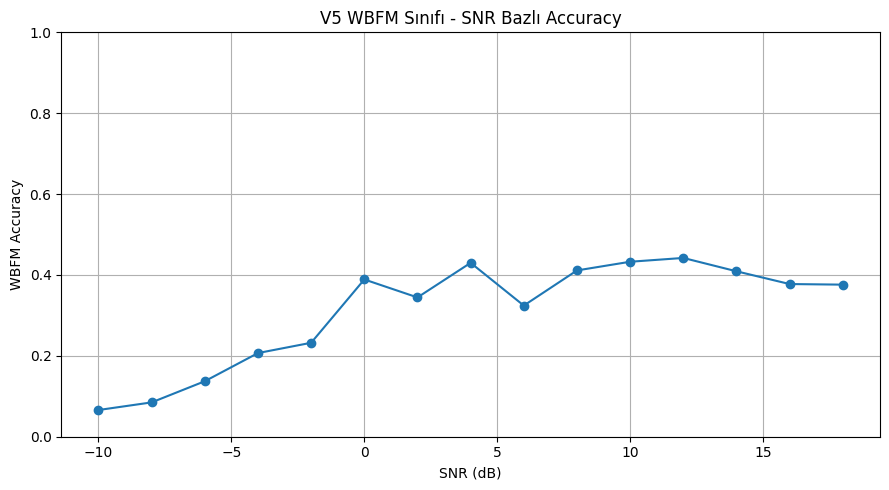

Kaydedildi: v5_wbfm_snr_accuracy.png


In [29]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("--- V5 SNR BAZLI WBFM ANALİZİ ---")

# 1. Train / Val / Test split işlemini label bilgisiyle birlikte tekrar yap
X_train_v5, X_temp_v5, Y_train_v5, Y_temp_v5, lbl_train_v5, lbl_temp_v5 = train_test_split(
    X_features_v5,
    temiz_Y,
    temiz_lbl,
    test_size=0.2,
    random_state=42,
    stratify=np.argmax(temiz_Y, axis=1)
)

X_val_v5, X_test_v5, Y_val_v5, Y_test_v5, lbl_val_v5, lbl_test_v5 = train_test_split(
    X_temp_v5,
    Y_temp_v5,
    lbl_temp_v5,
    test_size=0.5,
    random_state=42,
    stratify=np.argmax(Y_temp_v5, axis=1)
)

print("Test seti:", X_test_v5.shape)
print("Test label sayısı:", len(lbl_test_v5))

# 2. Kayıtlı normalization değerlerini yükle
mean_v5 = np.load("v5_feature_mean.npy")
std_v5 = np.load("v5_feature_std.npy")

# 3. Test setini normalize et
X_test_v5_norm = (X_test_v5 - mean_v5) / std_v5

# 4. Model tahminlerini al
Y_pred_v5 = model_v5.predict(X_test_v5_norm)

y_pred_v5 = np.argmax(Y_pred_v5, axis=1)
y_true_v5 = np.argmax(Y_test_v5, axis=1)

# 5. WBFM sınıf indexini bul
wbfm_index = mods.index("WBFM")

# 6. Test setindeki modülasyon ve SNR bilgilerini ayır
test_mods = np.array([lbl[0] for lbl in lbl_test_v5])
test_snrs = np.array([lbl[1] for lbl in lbl_test_v5])

# 7. Sadece gerçek WBFM örneklerini seç
wbfm_mask = test_mods == "WBFM"

wbfm_true = y_true_v5[wbfm_mask]
wbfm_pred = y_pred_v5[wbfm_mask]
wbfm_snrs = test_snrs[wbfm_mask]

print("Test setindeki WBFM örnek sayısı:", len(wbfm_true))

# 8. SNR bazlı WBFM accuracy hesapla
results = []

for snr in sorted(np.unique(wbfm_snrs)):
    snr_mask = wbfm_snrs == snr

    true_snr = wbfm_true[snr_mask]
    pred_snr = wbfm_pred[snr_mask]

    correct = np.sum(pred_snr == wbfm_index)
    total = len(true_snr)
    acc = correct / total if total > 0 else 0

    # WBFM en çok hangi sınıfa gitmiş?
    pred_counts = pd.Series(pred_snr).value_counts()
    most_pred_class_index = pred_counts.index[0]
    most_pred_class_name = mods[most_pred_class_index]
    most_pred_count = pred_counts.iloc[0]

    results.append({
        "SNR": snr,
        "WBFM_Total": total,
        "WBFM_Correct": correct,
        "WBFM_Accuracy": acc,
        "Most_Predicted_Class": most_pred_class_name,
        "Most_Predicted_Count": most_pred_count
    })

wbfm_snr_df = pd.DataFrame(results)

print("\n--- WBFM SNR BAZLI BAŞARI ---")
print(wbfm_snr_df)

# 9. CSV olarak kaydet
wbfm_snr_df.to_csv("v5_wbfm_snr_analysis.csv", index=False)
print("\nKaydedildi: v5_wbfm_snr_analysis.csv")

# 10. Grafik çiz
plt.figure(figsize=(9, 5))
plt.plot(
    wbfm_snr_df["SNR"],
    wbfm_snr_df["WBFM_Accuracy"],
    marker="o"
)

plt.title("V5 WBFM Sınıfı - SNR Bazlı Accuracy")
plt.xlabel("SNR (dB)")
plt.ylabel("WBFM Accuracy")
plt.ylim(0, 1)
plt.grid(True)
plt.tight_layout()
plt.savefig("v5_wbfm_snr_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

print("Kaydedildi: v5_wbfm_snr_accuracy.png")